In [10]:
import re

import nltk
import pandas as pd
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

nltk.download('stopwords')
nltk.download('punkt_tab')

stop_words = set(stopwords.words('russian'))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Ruslan\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Ruslan\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


In [11]:
def preprocess(text):
    text = text.lower()
    text = re.sub(r'[^а-яa-z\s]', '', text)
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]
    return tokens


df = pd.read_csv("../events/2_struct/2000-2025.csv")  #
df["tokens"] = df["event"].apply(preprocess)
df.head()

,date_start,date_end,event,tokens
0,2000-01-01,NaN,Деноминация белорусского рубля;,"[деноминация, белорусского, рубля]"
1,2000-01-01,NaN,"В связи с «проблемой-2000», в Иране объявлен н...","[связи, проблемой, иране, объявлен, нерабочий,..."
2,2000-01-01,NaN,"Вступление в силу закона в Великобритании, сог...","[вступление, силу, закона, великобритании, сог..."
3,2000-01-02,NaN,Крушение украинского сухогруза типа «река-море...,"[крушение, украинского, сухогруза, типа, рекам..."
4,2000-01-03,NaN,Обстрел из гранатомёта территории российского ...,"[обстрел, гранатомта, территории, российского,..."


In [12]:
from gensim.models import Word2Vec

corpus = df["tokens"].tolist()
model = Word2Vec(
    sentences=corpus,
    vector_size=100,  # размерность векторов
    window=5,
    min_count=2,
    sg=1  # skip-gram
)
# model.save("../models/word2vec_events.model")

In [13]:
import numpy as np


def vectorize(tokens):
    vectors = [model.wv[w] for w in tokens if w in model.wv]
    if len(vectors) == 0:
        return np.zeros(model.vector_size)
    return np.mean(vectors, axis=0)


df["vector"] = df["tokens"].apply(vectorize)
X = np.vstack(df["vector"].values)

In [14]:
import hdbscan

clusterer = hdbscan.HDBSCAN(min_cluster_size=3, metric='euclidean')
labels = clusterer.fit_predict(X)
df["cluster"] = labels

C:\Users\Ruslan\anaconda3\envs\data-core\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\Ruslan\anaconda3\envs\data-core\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [15]:
from collections import Counter

for cluster_id in sorted(df["cluster"].unique()):
    subset = df[df["cluster"] == cluster_id]
    tokens = [t for tokens in subset["tokens"] for t in tokens]
    common = Counter(tokens).most_common(10)
    print(f"\nКластер {cluster_id}: {[w for w, _ in common]}")


Кластер -1: ['человек', 'выборы', 'погибли', 'президента', 'россии', 'сша', 'президент', 'результате', 'года', 'победу']

Кластер 0: ['выборы', 'парламентские', 'президентские', 'свазиленде', 'омане', 'кувейте', 'белизе', 'кюрасао']

Кластер 1: ['космического', 'корабля', 'союз', 'международным', 'экипажем', 'старт', 'тмам', 'международной', 'космической', 'станции']

Кластер 2: ['выборы', 'тур', 'первый', 'парламентские', 'президентские', 'иране', 'румынии', 'хорватии', 'второй', 'абхазии']

Кластер 3: ['избран', 'президентом', 'венгрии', 'новым', 'иполито', 'мехия', 'доминиканской', 'республики', 'ференц', 'мадл']

Кластер 4: ['партия', 'парламентских', 'победу', 'одержала', 'выборах', 'проведение', 'выборов', 'досрочных', 'греции', 'новая']

Кластер 5: ['чемпионат', 'мира', 'хоккею', 'шайбой', 'крлингу', 'летбридж', 'канада', 'велотреку', 'колумбии']

Кластер 6: ['выборы', 'президента', 'молдовы', 'малави', 'колумбии', 'туниса', 'президентские', 'эстонии', 'пост', 'избрана']

Класт

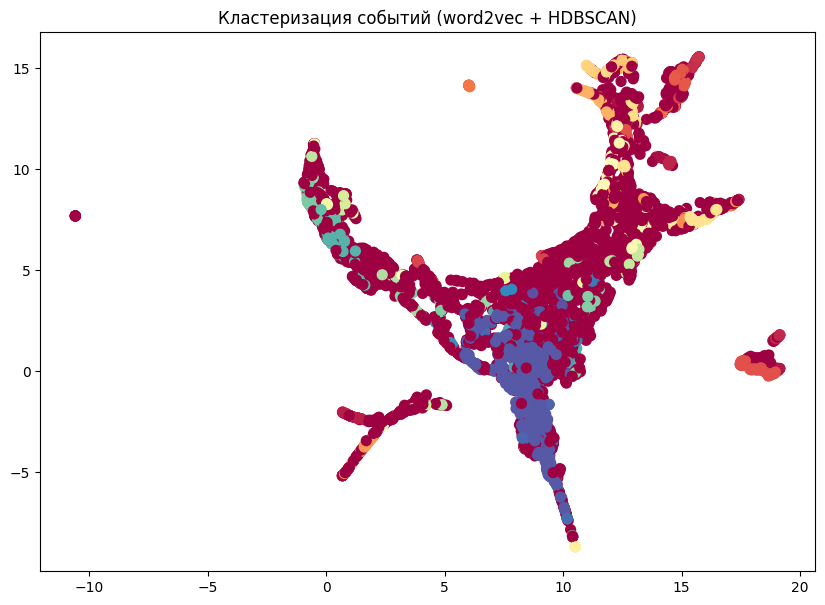

In [17]:
import umap
import matplotlib.pyplot as plt

umap_embeddings = umap.UMAP(n_neighbors=15, min_dist=0.1).fit_transform(X)

plt.figure(figsize=(10, 7))
plt.scatter(umap_embeddings[:, 0], umap_embeddings[:, 1],
            c=df["cluster"], cmap="Spectral", s=50)
plt.title("Кластеризация событий (word2vec + HDBSCAN)")
plt.show()

In [20]:
from sklearn.metrics import silhouette_score

mask = labels != -1
score = silhouette_score(X[mask], labels[mask])
score

0.0949711422153127

In [22]:
import itertools
import numpy as np
import pandas as pd
from gensim.models import Word2Vec
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import hdbscan
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore")


# corpus нужна переменная для токенов

# ==== 2. Функция векторизации текста ====
def vectorize(tokens, model):
    vectors = [model.wv[w] for w in tokens if w in model.wv]
    if len(vectors) == 0:
        return np.zeros(model.vector_size)
    return np.mean(vectors, axis=0)

# ==== 3. Пространство гиперпараметров ====
param_grid = {
    "vector_size": [100, 200, 300],
    "window": [3, 5, 8, 10],
    "min_count": [1, 2, 5],
    "sg": [0, 1],  # 0 — CBOW, 1 — Skip-gram
}

param_combinations = list(itertools.product(*param_grid.values()))
param_names = list(param_grid.keys())

results = []

# ==== 4. Перебор параметров ====
for params in tqdm(param_combinations, desc="Grid Search Word2Vec"):
    param_dict = dict(zip(param_names, params))

    # 4.1 Обучаем Word2Vec
    model = Word2Vec(
        sentences=corpus,
        **param_dict,
        workers=4,
        epochs=20,
        seed=42
    )

    # 4.2 Векторизация событий
    X = np.vstack([vectorize(tokens, model) for tokens in corpus])

    # 4.3 Кластеризация (можно выбрать KMeans или HDBSCAN)
    # HDBSCAN (автоматически подбирает число кластеров)
    clusterer = hdbscan.HDBSCAN(min_cluster_size=5)
    labels = clusterer.fit_predict(X)

    # Игнорируем шумовые точки (-1)
    mask = labels != -1
    if len(set(labels[mask])) < 2:
        continue

    # ==== 4.4 Метрики ====
    sil = silhouette_score(X[mask], labels[mask])
    db = davies_bouldin_score(X[mask], labels[mask])
    ch = calinski_harabasz_score(X[mask], labels[mask])

    results.append({
        **param_dict,
        "silhouette": sil,
        "davies_bouldin": db,
        "calinski_harabasz": ch,
        "clusters": len(set(labels[mask]))
    })

# ==== 5. Анализ результатов ====
results_df = pd.DataFrame(results)
results_df = results_df.sort_values("silhouette", ascending=False)

print("\nЛучшие параметры по silhouette:")
print(results_df.head(10))

# Можно также вывести среднюю оценку с весами
results_df["score_combined"] = (
    results_df["silhouette"] * 2
    - results_df["davies_bouldin"] * 0.5
    + np.log1p(results_df["calinski_harabasz"]) * 0.1
)

print("\nТоп по комбинированному скору:")
print(results_df.sort_values("score_combined", ascending=False).head(10))

Grid Search Word2Vec: 100%|██████████| 72/72 [06:31<00:00,  5.44s/it]


Лучшие параметры по silhouette:
    vector_size  window  min_count  sg  silhouette  davies_bouldin  \
29          200       3          5   1    0.460922        0.775778   
53          300       3          5   1    0.458550        0.779017   
5           100       3          5   1    0.445275        0.791237   
59          300       5          5   1    0.439719        0.868720   
15          100       8          2   1    0.419142        0.783482   
63          300       8          2   1    0.419103        0.807909   
14          100       8          2   0    0.418720        0.660160   
55          300       5          1   1    0.417267        0.793201   
11          100       5          5   1    0.406132        0.881603   
69          300      10          2   1    0.402464        0.842333   

    calinski_harabasz  clusters  
29         411.027393        63  
53         383.943392        69  
5          371.782820        66  
59         301.856154        73  
15         284.058473     

In [24]:
# === 1. Обучаем Word2Vec с выбранными параметрами ===
best_params = {
    "vector_size": 200,
    "window": 3,
    "min_count": 5,
    "sg": 1,           # Skip-gram
    "workers": 4,
    "epochs": 20,
    "seed": 42
}

corpus = df["tokens"].tolist()
model = Word2Vec(sentences=corpus, **best_params)

# === 2. Векторизация событий ===
def vectorize(tokens):
    vectors = [model.wv[w] for w in tokens if w in model.wv]
    if len(vectors) == 0:
        return np.zeros(model.vector_size)
    return np.mean(vectors, axis=0)

X = np.vstack(df["tokens"].apply(vectorize).values)

# === 3. Кластеризация (можно поменять min_cluster_size) ===
clusterer = hdbscan.HDBSCAN(min_cluster_size=5, metric='euclidean')
labels = clusterer.fit_predict(X)

df["cluster"] = labels

# === 4. Метрики качества ===
mask = labels != -1
if len(set(labels[mask])) > 1:
    sil = silhouette_score(X[mask], labels[mask])
    db = davies_bouldin_score(X[mask], labels[mask])
    ch = calinski_harabasz_score(X[mask], labels[mask])
    print(f"Silhouette: {sil:.3f}, Davies–Bouldin: {db:.3f}, Calinski–Harabasz: {ch:.1f}")
else:
    print("Недостаточно кластеров для расчёта метрик")

# === 5. Сводка по кластерам ===
print("\n📊 Кластеры:")
print(df["cluster"].value_counts().sort_index())

# === 6. Вывод топ-слов по каждому кластеру ===
for cluster_id in sorted(df["cluster"].unique()):
    if cluster_id == -1:
        continue
    subset = df[df["cluster"] == cluster_id]
    tokens = [t for tokens in subset["tokens"] for t in tokens if t in model.wv]
    top_words = [w for w, _ in Counter(tokens).most_common(30)]
    print(f"\nКластер {cluster_id}: {top_words}")

Silhouette: 0.457, Davies–Bouldin: 0.781, Calinski–Harabasz: 369.7

📊 Кластеры:
cluster
-1     4011
 0        6
 1       18
 2       11
 3       32
       ... 
 63      12
 64       7
 65      19
 66       6
 67      10
Name: count, Length: 69, dtype: int64

Кластер 0: ['россии']

Кластер 1: ['единый', 'день', 'голосования', 'россии', 'прошл', 'первый', 'второй', 'россия', 'проведение', 'выборов', 'государственную', 'думу', 'беларуси']

Кластер 2: ['форум', 'казахстана', 'россии', 'межрегионального', 'сотрудничества', 'россия', 'казахстан', 'приграничных', 'регионов', 'iii', 'vii', 'сочи', 'астана']

Кластер 3: []

Кластер 4: ['шаттла', 'полт', 'шаттл', 'старт', 'программе', 'спейс', 'sts', 'экипаж', 'продолжение', 'строительства', 'международной', 'космической', 'станции', 'атлантис', 'дискавери', 'майкл', 'индевор', 'джеймс', 'россия', 'стивен', 'марк', 'келли', 'япония', 'скотт', 'ричард', 'роберт', 'джон', 'юрий', 'канада', 'кеннет']

Кластер 5: ['игры', 'олимпийские', 'летние', 'з

🔄 Кодируем тексты в эмбеддинги...


Batches:   0%|          | 0/177 [00:00<?, ?it/s]

✅ Получено 5649 эмбеддингов размерности 384

🔍 Выполняем кластеризацию HDBSCAN...


C:\Users\Ruslan\anaconda3\envs\data-core\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\Ruslan\anaconda3\envs\data-core\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(



📈 Метрики качества кластеров:
Silhouette Score: 0.1914
Davies–Bouldin Index: 1.3683
Calinski–Harabasz Score: 29.5

📊 Распределение по кластерам:
cluster
-1     4788
 0        5
 1       10
 2       17
 3       11
 4        5
 5        5
 6       10
 7        9
 8        5
 9       45
 10       5
 11       6
 12      11
 13      14
 14       9
 15     172
 16       5
 17       9
 18       5
 19       8
 20      20
 21       6
 22       7
 23      19
 24       7
 25       6
 26       5
 27       9
 28      29
 29       5
 30       6
 31      12
 32       5
 33      16
 34      10
 35      10
 36      77
 37      20
 38      12
 39      11
 40     184
 41      19
Name: count, dtype: int64


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Ruslan\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Ruslan\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!



Кластер 0 (5 событий): ['год', 'сша', 'нобелевская', 'премия', 'присуждена', 'физике', 'англ', 'университет', 'развитие', 'квантовой']

Кластер 1 (10 событий): ['apple', 'компания', 'представила', 'iphone', 'операционную', 'систему', 'mac', 'первое', 'поколение', 'смартфона']

Кластер 2 (17 событий): ['windows', 'microsoft', 'выход', 'server', 'выпустила', 'операционную', 'систему', 'компания', 'поддержки', 'корпорация']

Кластер 3 (11 событий): ['затмение', 'солнечное', 'полное', 'территории', 'африки', 'фаза', 'видно', 'австралии', 'кольцеобразное', 'наблюдалось']

Кластер 4 (5 событий): ['однополые', 'браки', 'мире', 'однополых', 'браков', 'нидерланды', 'стали', 'первой', 'страной', 'узаконившей']

Кластер 5 (5 событий): ['папы', 'римского', 'папой', 'римским', 'xvi', 'xiv', 'глава', 'конгрегации', 'вопросам', 'вероучения']

Кластер 6 (10 событий): ['начало', 'вещания', 'телеканала', 'тнт', 'твс', 'международного', 'ртр', 'планета', 'звезда', 'домашний']

Кластер 7 (9 событий): ['д

C:\Users\Ruslan\anaconda3\envs\data-core\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


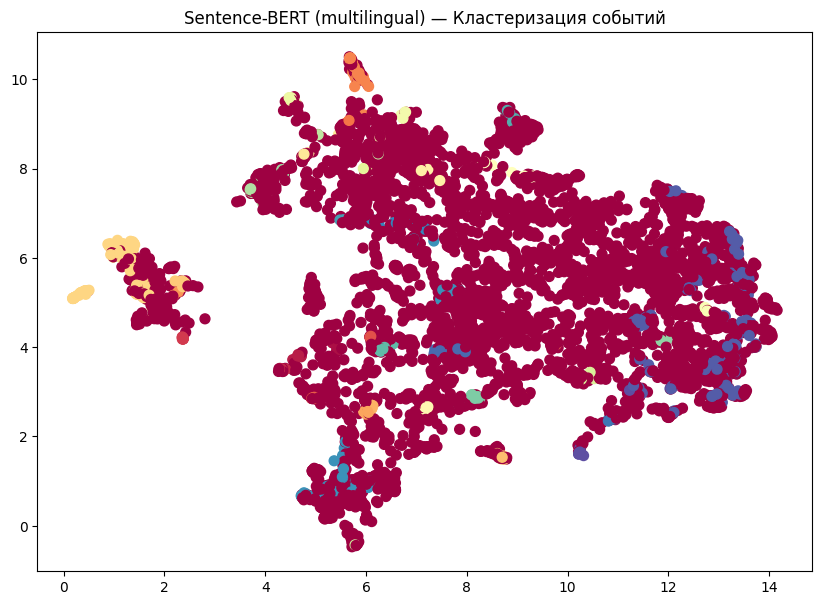

In [2]:
# === 1. Импорт библиотек ===
import pandas as pd
import numpy as np
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sentence_transformers import SentenceTransformer
import hdbscan
from collections import Counter
import umap
import matplotlib.pyplot as plt

# === 2. Данные ===

df = pd.read_csv("../events/2_struct/2000-2025.csv")  #

# === 3. Модель Sentence-BERT (многоязычная, понимает русский) ===
model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')

# === 4. Кодирование текстов ===
print("🔄 Кодируем тексты в эмбеддинги...")
X = model.encode(df["event"], show_progress_bar=True, convert_to_numpy=True, normalize_embeddings=True)

print(f"✅ Получено {X.shape[0]} эмбеддингов размерности {X.shape[1]}")

# === 5. Кластеризация HDBSCAN ===
print("\n🔍 Выполняем кластеризацию HDBSCAN...")
clusterer = hdbscan.HDBSCAN(min_cluster_size=5, metric='euclidean')
labels = clusterer.fit_predict(X)
df["cluster"] = labels

# === 6. Метрики кластеризации ===
mask = labels != -1  # убираем шум
if len(set(labels[mask])) > 1:
    sil = silhouette_score(X[mask], labels[mask])
    db = davies_bouldin_score(X[mask], labels[mask])
    ch = calinski_harabasz_score(X[mask], labels[mask])
    print(f"\n📈 Метрики качества кластеров:")
    print(f"Silhouette Score: {sil:.4f}")
    print(f"Davies–Bouldin Index: {db:.4f}")
    print(f"Calinski–Harabasz Score: {ch:.1f}")
else:
    print("Недостаточно кластеров для расчёта метрик (все тексты попали в один кластер).")

# === 7. Сводка по кластерам ===
print("\n📊 Распределение по кластерам:")
print(df["cluster"].value_counts().sort_index())

# === 8. Топ-слова (по простому токенизатору) ===
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import nltk
nltk.download("stopwords")
nltk.download("punkt")

russian_stopwords = set(stopwords.words("russian"))

def tokenize(text):
    text = re.sub(r"[^а-яА-Яa-zA-Z\s]", " ", text.lower())
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in russian_stopwords and len(t) > 2]
    return tokens

df["tokens"] = df["event"].apply(tokenize)

for cluster_id in sorted(df["cluster"].unique()):
    if cluster_id == -1:
        continue
    subset = df[df["cluster"] == cluster_id]
    tokens = [t for tokens in subset["tokens"] for t in tokens]
    common = Counter(tokens).most_common(10)
    print(f"\nКластер {cluster_id} ({len(subset)} событий): {[w for w, _ in common]}")

# === 9. Визуализация UMAP ===
print("\n🎨 Строим 2D-визуализацию UMAP...")
umap_embeddings = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42).fit_transform(X)

plt.figure(figsize=(10, 7))
plt.scatter(umap_embeddings[:, 0], umap_embeddings[:, 1], c=df["cluster"], cmap="Spectral", s=50)
plt.title("Sentence-BERT (multilingual) — Кластеризация событий")
plt.show()